In [1]:
from utils import *
import sys 
sys.path.append('..')

Degree of freedom:  2601


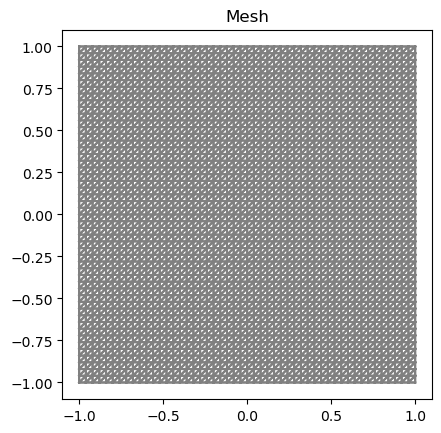

In [2]:
mesh = fn.RectangleMesh(fn.Point(-1, -1), fn.Point(1, 1), 50, 50)
fn.plot(mesh, title='Mesh')
V = fn.FunctionSpace(mesh, 'CG', 1)
print('Degree of freedom: ', V.dim())
u_trial, u_test = fn.TrialFunction(V), fn.TestFunction(V)
M_matrix = fn.assemble(u_trial * u_test * fn.dx)
P_matrix = fn.assemble(u_trial * u_test * fn.dP)
P_solver = Operator2Solver(P_matrix)
fn.plot(mesh)

In [3]:
class Boundary(fn.SubDomain):
    def inside(self, x, on_boundary):
        left = x[0] < 0.75 + fn.DOLFIN_EPS and x[0] > -0.75 - fn.DOLFIN_EPS
        right = x[1] < 0.75 + fn.DOLFIN_EPS and x[1] > -0.75 - fn.DOLFIN_EPS
        return left and right

# Create a MeshFunction to mark boundaries
subdomains = fn.MeshFunction('size_t', mesh, mesh.topology().dim(), 0)
boundary = Boundary()
boundary.mark(subdomains, 1)  # Mark the left subdomain with the value 1

# Create a measure for the boundary
dx = fn.Measure('dx', domain=mesh, subdomain_data=subdomains)
ds = comp_dS(mesh, subdomains)

In [4]:
# Setting of the problem:
c = 300.    # Sound speed.

# Define simulation times:
T = 0.2
dt = 0.0005
simulation_times = np.arange(0., T + 0.5 * dt, dt)

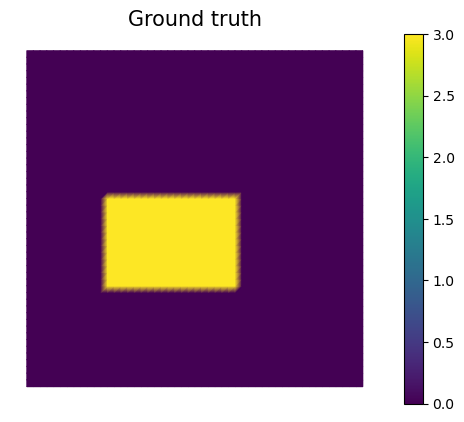

In [5]:
# Initial condition:
class RectangleExpression(fn.UserExpression):
    def eval(self, value, x):
        # Define the boundaries of the smaller L-shape within the square [-0.8, 0.8] x [-0.8, 0.8]
        if x[0] >= -0.55 - fn.DOLFIN_EPS and x[0] <= 0.25 + fn.DOLFIN_EPS and x[1] >= -0.4 - fn.DOLFIN_EPS and x[1] <= 0.125 + fn.DOLFIN_EPS:
            value[0] = 3.0  # Value inside the smaller L-shape
        # Define a circle with radius 0.5 and center (0.1, -0.1)
        # elif (x[0] - 0.25)**2 + (x[1] + 0.125)**2 <= 0.3**2:
        #     value[0] = 3.0  # Value inside the circle
        else:
            value[0] = 0.0  # Value outside the smaller L-shape

    def value_shape(self):
        return ()

ic_expr = RectangleExpression(element=V.ufl_element())
u_init = fn.interpolate(ic_expr, V).vector()
im = nb.plot(fn.Function(V, u_init), colorbar=False)
plt.colorbar(pad = 0.05)
plt.title('Ground truth', fontsize=15)
# Export plot to pdf with short marginal:
plt.savefig('ground_truth.pdf', bbox_inches='tight')
# Export:

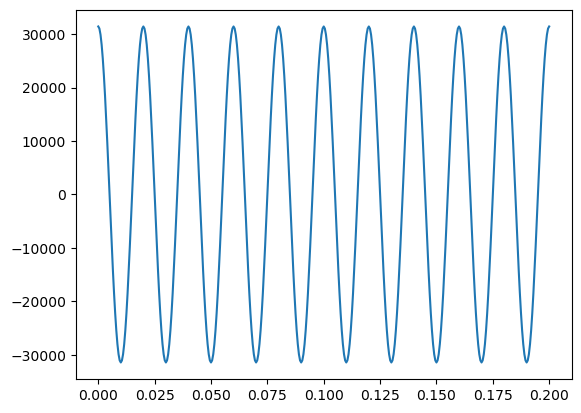

In [6]:
# Boundary condition:
bc = fn.DirichletBC(V, 0., "on_boundary")
bc.apply(u_init)
# Source term:
# x_opt = np.array([169.39527187,  87.9642005 ,  59.61256589,  45.40571795, 37.62224378])
x_opt = np.array([100., 0., 0., 0., 0.])
# x_opt = np.array([0., 0., 0., 0., 80.])
i_true_time_func = lambda t: (100 * np.pi * x_opt[0] * np.cos(100 * np.pi * t) 
                              + 200 * np.pi * x_opt[1] * np.cos(200 * np.pi * t)
                              + 300 * np.pi * x_opt[2] * np.cos(300 * np.pi * t)  
                              + 400 * np.pi * x_opt[3] * np.cos(400 * np.pi * t)
                              + 500 * np.pi * x_opt[4] * np.cos(500 * np.pi * t))
# i_true_time_func = lambda t: (100 * np.pi * x_opt_4[0] * np.cos(100 * np.pi * t) + 200 * np.pi * x_opt_4[1] * np.cos(200 * np.pi * t) + 300 * np.pi * x_opt_4[2] * np.cos(300 * np.pi * t) + 150 * np.pi * x_opt_4[3] * np.cos(150 * np.pi * t))
# i_true_time_int = i_true_time_int_func(simulation_times)
i_true_time = i_true_time_func(simulation_times)
f_true = space_time_mult(i_true_time, u_init, M_matrix, simulation_times)
# Zero vectors:
zero_vec = init_vector(M_matrix, 0)
zero_time_vec = init_time_vector(M_matrix, simulation_times, 0)
plt.plot(simulation_times, i_true_time)
# 
# # Compute L2 norm:
# from scipy.integrate import simps
# result_1 = simps(i_true_time * i_true_time, simulation_times)
# print('L2 norm: ', result_1)
# result_2 = simps(i_true_time_int * i_true_time_int, simulation_times)
# print('L2 norm of integral: ', result_2)

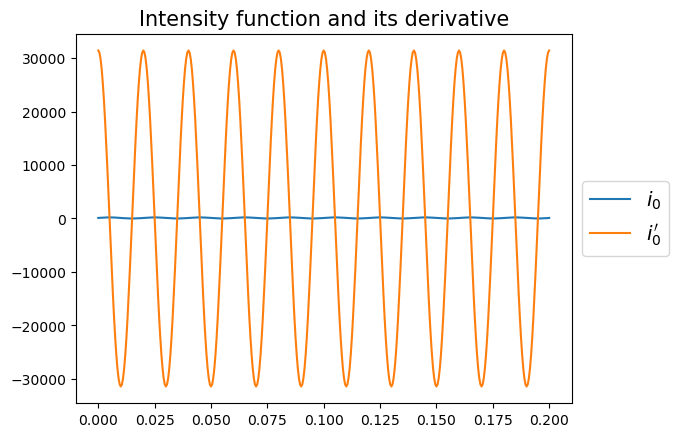

In [7]:
# Plot i:
i_int_func_time = lambda t: 100 * (np.sin(100 * np.pi * t) + 1)
i_int_time = i_int_func_time(simulation_times)
plt.plot(simulation_times, i_int_time)
# Plot i':
i_prime_func_time = lambda t: 100 * (100 * np.pi * np.cos(100 * np.pi * t))
i_prime_time = i_prime_func_time(simulation_times)
plt.plot(simulation_times, i_prime_time)
# Add bigger legend outside the plot:
plt.legend(['$i_0$', '$i_0\'$'], loc='center left', bbox_to_anchor=(1, 0.5), fontsize='x-large')
# Add title:
plt.title('Intensity function and its derivative', fontsize=15)
# Export plot to pdf with short marginal:
plt.savefig('opt_i_i_prime.pdf', bbox_inches='tight')


In [8]:
# Compute H1 norm:
from scipy.integrate import simps
result = simps(i_true_time * i_true_time, simulation_times)
print('H1 norm: ', result)

H1 norm:  98696044.01089358


In [9]:
# Solve forward problem:
from WaveNewmarkFractional import *
c_expr = fn.Constant(c)
# alpha = 0.1
alpha = 0.3
# alpha = 0.8
b = (-(2 * c) / np.cos(np.pi * (alpha + 1)/ 2) )
print(b)
# b = 0.3835
b = 0.1321
# b = 0.0631
parameter = [c_expr, b, alpha]

1321.6135587511603


In [10]:
# Observation operator:
u_trial, u_test = fn.TrialFunction(V), fn.TestFunction(V)
B_matrix = fn.assemble(fn.inner(u_trial('+'), u_test('+')) * ds(1))
_misfit = WaveSpaceTimeStateObservation(V, simulation_times, simulation_times, B_matrix)

In [11]:
gamma = 1.
delta = 8.
_prior = LaplacianPrior(V, gamma, delta)
from WaveSolver import *
WaveNewModel = WaveInverseDamped(V, simulation_times, _misfit, _prior, parameter)

In [12]:
design = i_true_time
X_zero = WaveNewModel.generate_vector()
X_zero[PARAMETER][:] = u_init[:]
WaveNewModel.solveFwd(X_zero[STATE], X_zero, design)
WaveNewModel.misfit.p_obs = X_zero[STATE].copy()
WaveNewModel.misfit.noise_variance = 1e-2
parRandom.normal_perturb(WaveNewModel.misfit.noise_variance, WaveNewModel.misfit.p_obs)
print(WaveNewModel.cost(X_zero))

[321.48865522773974, 321.4848000000017, 0.0038552277380149015]


In [13]:
from Jacobian import *
design = i_true_time
J_new = Jacobian_PAT(WaveNewModel, design)
H_new = Hessian_PAT(WaveNewModel, design)

In [16]:
k = 80
p = 20
print( "Single Pass Algorithm. Requested eigenvectors: {0}; Oversampling {1}.".format(k,p))
Omega = MultiVector(X_zero[PARAMETER], k + p)
parRandom.normal(1., Omega)
lmbda, Z = singlePassG(H_new, _prior.R, _prior.Rsolver, Omega, k)
_posterior = GaussianLRPosterior(_prior, lmbda, Z)

Single Pass Algorithm. Requested eigenvectors: 80; Oversampling 20.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forwar

In [14]:
X_iter_2 = WaveNewModel.generate_vector()
solution = np.load('data/03_100_init_Laplacian.npy')
u_comp = init_vector_numpy(solution)
X_iter_2[PARAMETER][:] = u_comp[:]
SteinhaugSolver = CGSolverSteihaug()
SteinhaugSolver.set_operator(J_new)
SteinhaugSolver.set_preconditioner(P_solver)
SteinhaugSolver.parameters["print_level"] = 1
SteinhaugSolver.parameters["rel_tolerance"] = 1e-3
SteinhaugSolver.parameters["abs_tolerance"] = 1e-3
SteinhaugSolver.parameters["max_iter"] = 1000
SteinhaugSolver.parameters["zero_initial_guess"] = False
SteinhaugSolver.solve(X_iter_2[PARAMETER], J_new.M_b)

 Iteration :  0  (B r, r) =  9.803107322919542


KeyboardInterrupt: 

In [15]:
WaveNewModel.solveFwd(X_iter_2[STATE], X_iter_2, design)
print(WaveNewModel.cost(X_iter_2))
# Compute L2 norm:
diff = X_iter_2[PARAMETER] - X_zero[PARAMETER]
norm = np.sqrt(diff.inner(M_matrix * diff))
norm_zero = np.sqrt(X_zero[PARAMETER].inner(M_matrix * X_zero[PARAMETER]))
print('Relative L2 error: ', norm/norm_zero)

[56.40224991770395, 50.40709147710008, 5.995158440603869]
Relative L2 error:  0.35665887571842375


In [20]:
# Export solution to numpy:
np.save('data/03_100_init_Laplacian.npy', X_iter_2[PARAMETER][:])